# Import Libraries

In [24]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import pickle
import streamlit as st

# Load Dataset

In [25]:
df = pd.read_csv("loan_approval_data.csv",encoding = "unicode_escape")

# Data Exploration

In [26]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [27]:
df.tail()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes
999,1000.0,13093.0,2385.0,Salaried,23.0,Married,1.0,613.0,3.0,0.32,12436.0,25816.0,35818.0,48.0,Personal,Semiurban,Graduate,NaN,Private,No


In [28]:
df.shape

(1000, 20)

In [29]:
df.columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [31]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [32]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Heatmap

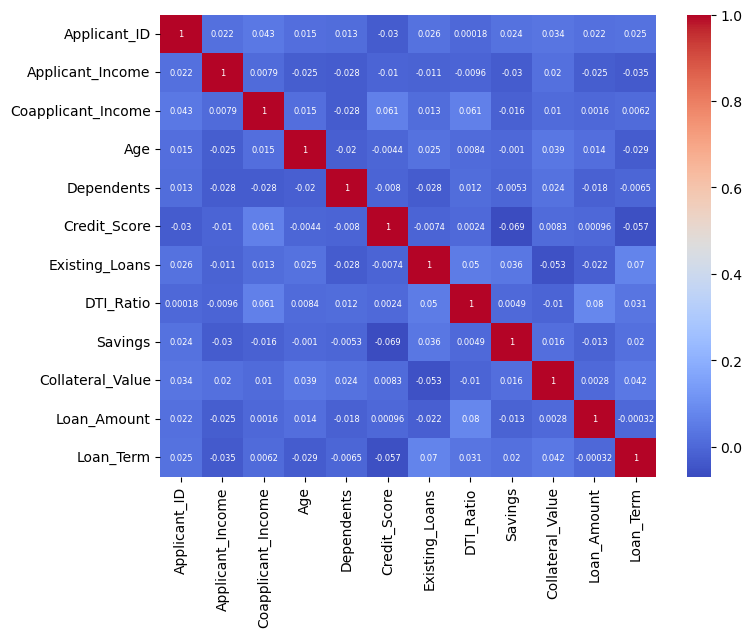

In [33]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws = {"size":6},
    cmap="coolwarm"
    )
plt.show()

# Handling Missing Values

In [34]:
imputer_mean = SimpleImputer(strategy="mean")

cols = ["Applicant_Income","Coapplicant_Income","Age","Dependents","Credit_Score","Existing_Loans","DTI_Ratio","Savings","Collateral_Value","Loan_Amount","Loan_Term"]
df[cols]=imputer_mean.fit_transform(df[cols])

imputer_freq = SimpleImputer(strategy = "most_frequent")

df[["Marital_Status","Loan_Purpose","Property_Area","Education_Level","Gender","Employment_Status","Employer_Category","Loan_Approved"]] = imputer_freq.fit_transform(df[["Marital_Status","Loan_Purpose","Property_Area","Education_Level","Gender","Employment_Status","Employer_Category","Loan_Approved"]])


In [35]:
columns = ["Applicant_ID","Loan_Approved"]

x = df.drop(columns,axis=1)
y = df["Loan_Approved"]

# Scaling

In [36]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols = ["Applicant_Income","Coapplicant_Income","Savings","Collateral_Value"]	
x[cols] = scaler.fit_transform(x[cols])

In [37]:
x.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category
0,1.407951,-1.288905,Salaried,51.0,Married,0.0,637.0,4.0,0.53,1.657382,1.490881,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private
1,-1.620925,-0.838280,Salaried,46.0,Married,3.0,621.0,2.0,0.30,-1.289197,1.750915,38687.0,48.0,Car,Semiurban,Graduate,Male,Private
2,-0.702223,-1.038131,Salaried,25.0,Single,2.0,674.0,4.0,0.20,0.683713,-1.280477,27943.0,72.0,Business,Urban,Graduate,Female,Government
3,0.631010,1.077923,Salaried,40.0,Married,2.0,579.0,3.0,0.31,-0.067863,-0.998834,27819.0,60.0,Business,Rural,Graduate,Female,Government
4,0.493103,-0.299762,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,-0.097113,0.917790,12741.0,72.0,Car,Urban,Graduate,Male,Private


# 
Encoding

In [38]:
#one hote encoding
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_cols = ["Marital_Status","Employment_Status","Loan_Purpose","Property_Area","Education_Level","Gender","Employment_Status","Employer_Category"]
enc_cols= ohe.fit_transform(x[cat_cols])
enc_x = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=x.index)

x_encoded= pd.concat([x.drop(columns=cat_cols),enc_x], axis=1)

In [39]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
x_encoded.isnull().sum()

Applicant_Income                   0
Coapplicant_Income                 0
Age                                0
Dependents                         0
Credit_Score                       0
Existing_Loans                     0
DTI_Ratio                          0
Savings                            0
Collateral_Value                   0
Loan_Amount                        0
Loan_Term                          0
Marital_Status_Married             0
Marital_Status_Single              0
Employment_Status_Contract         0
Employment_Status_Salaried         0
Employment_Status_Self-employed    0
Employment_Status_Unemployed       0
Loan_Purpose_Business              0
Loan_Purpose_Car                   0
Loan_Purpose_Education             0
Loan_Purpose_Home                  0
Loan_Purpose_Personal              0
Property_Area_Rural                0
Property_Area_Semiurban            0
Property_Area_Urban                0
Education_Level_Graduate           0
Education_Level_Not Graduate       0
G

# Train-Test Split

In [40]:
x_encoded_train,x_encoded_test,y_encoded_train,y_encoded_test = train_test_split(
    x_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42)

# Model Training

# Logistic Regression(L2)

In [41]:
#ridge = l2 penalty
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(penalty='l2',solver='lbfgs',max_iter=10000)
model1.fit(x_encoded_train,y_encoded_train)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [42]:
y_pred = model1.predict(x_encoded_test)

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_encoded_test,y_pred)
cm= confusion_matrix(y_encoded_test,y_pred)
cr = classification_report(y_encoded_test,y_pred)
print("accuracy:",accuracy)
print("confusion_matrix:",cm)
print("classification_report:",cr)

accuracy: 0.845
confusion_matrix: [[128  11]
 [ 20  41]]
classification_report:               precision    recall  f1-score   support

           0       0.86      0.92      0.89       139
           1       0.79      0.67      0.73        61

    accuracy                           0.84       200
   macro avg       0.83      0.80      0.81       200
weighted avg       0.84      0.84      0.84       200



# Logistic Rgression(L1)

In [44]:
#lasso l1 penalty
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty='l1',solver='liblinear')
model.fit(x_encoded_train,y_encoded_train)


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [45]:
y_pred = model.predict(x_encoded_test)
accuracy = accuracy_score(y_encoded_test,y_pred)
cm= confusion_matrix(y_encoded_test,y_pred)
cr = classification_report(y_encoded_test,y_pred)
print("accuracy:",accuracy)
print("confusion_matrix:",cm)
print("classification_report:",cr)

accuracy: 0.88
confusion_matrix: [[129  10]
 [ 14  47]]
classification_report:               precision    recall  f1-score   support

           0       0.90      0.93      0.91       139
           1       0.82      0.77      0.80        61

    accuracy                           0.88       200
   macro avg       0.86      0.85      0.86       200
weighted avg       0.88      0.88      0.88       200



# Random Forest

In [46]:
#RandomForest classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42)
rf.fit(x_encoded_train,y_encoded_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
y_pred = rf.predict(x_encoded_test)
accuracy = accuracy_score(y_encoded_test,y_pred)
cm= confusion_matrix(y_encoded_test,y_pred)
cr = classification_report(y_encoded_test,y_pred)
print("accuracy:",accuracy)
print("confusion_matrix:",cm)
print("classification_report:",cr)

accuracy: 0.91
confusion_matrix: [[130   9]
 [  9  52]]
classification_report:               precision    recall  f1-score   support

           0       0.94      0.94      0.94       139
           1       0.85      0.85      0.85        61

    accuracy                           0.91       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.91      0.91      0.91       200



# Confusion Matrix

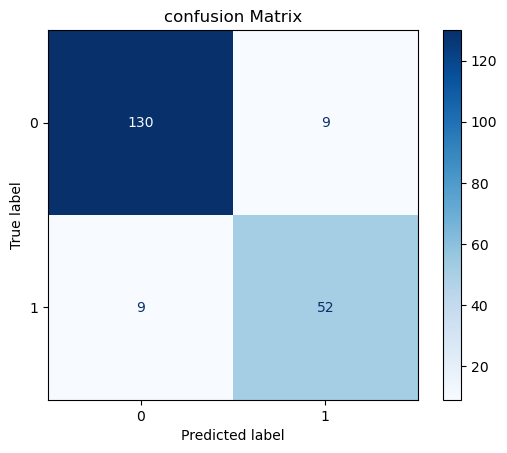

In [48]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf.predict(x_encoded_test)
cm = confusion_matrix(y_encoded_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("confusion Matrix")
#plt.savefig("image/confusion_matrix.png",dpi=300, bbox_inches = "tight")
plt.show()

# Accuracy Comparison

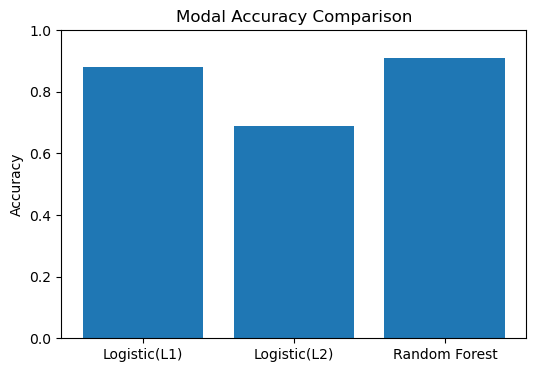

In [49]:
models = ["Logistic(L1)","Logistic(L2)","Random Forest"]
accuracy = [0.88,0.69,0.91]
plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Modal Accuracy Comparison")
plt.show()

In [50]:
#Save the model
import joblib 
joblib.dump(rf, "loan_model.pkl")

['loan_model.pkl']